In [1]:
import numpy as np
from lshade_cop import LSHADE_COP
import matplotlib.pyplot as plt
from geomdl import NURBS, BSpline
from shapely.geometry import Polygon, Point, LineString
from __utils import *
import pickle
import imageio

In [ ]:
RADIUS = 0.15/2
KAPPA_MAX = 8#1/RADIUS
LAMBDA = RADIUS*2
DEGREE = 5
NUM_FREE_CTRLPTS = 4
NUM_STATIC_CTRLPTS = 2*DEGREE + 4
SPACE_DIM = 2
NSAMPLING = 100
NUM_POINTS = 100

N_RUNS = 1
DEBUG = 0
pop_size = 216//2#9*dim #9*dim  # Population size
max_fes = 12000#2500  # Maximum number of function evaluations


seed = 2  # escolha qualquer número inteiro
random.seed(seed)
np.random.seed(seed)

In [3]:
# ---------------------------------------------------
# PARAMETERS ENVIRONMENT
# ---------------------------------------------------
width, height = 3.2, 2.0   # environment dimensions
Nobs = 8                   # number of polygons
poly_size = 0.3            # average "radius" of polygons
safe_radius = 0.4          # radius of safe zones around start/goal
line_width = 2

# Workspace boundaries centered at (0,0)
xmin_env, xmax_env = -width/2, width/2
ymin_env, ymax_env = -height/2, height/2
workspace = Polygon([(xmin_env, ymin_env), (xmax_env, ymin_env),
                     (xmax_env, ymax_env), (xmin_env, ymax_env)])


# Minimum and maximum polygon area
r = RADIUS
A_min = 2 * np.pi * r**2   # ~0.141 m^2
A_max = 0.2                # example maximum

# Start and Goal points
start = np.array([-1.4, -0.8])
goal  = np.array([ 1.4,  0.8])

# Safe zones
safe_zones = [Point(start).buffer(safe_radius),
              Point(goal).buffer(safe_radius)]

obstacles = generate_polygons(Nobs, xmin_env, xmax_env, ymin_env, ymax_env, poly_size, safe_zones, A_min, A_max)
# Expande os polígonos pelo raio do robô
expanded_obs = [poly.buffer(RADIUS) for poly in obstacles]

In [7]:
list_of_static_params = []

agent_params1 = get_static_params(np.deg2rad(0), np.deg2rad(-45), np.array([-1.3, -0.7]), np.array([1.3, 0.7]), id=1)
list_of_static_params.append(agent_params1)

17.500203168368973
[[-1.3        -0.7       ]
 [-1.3        -0.7       ]
 [-1.3        -0.7       ]
 [-1.3        -0.7       ]
 [-1.3        -0.7       ]
 [-1.2        -0.7       ]
 [-1.15       -0.7       ]
 [-0.6812132  -0.2987868 ]
 [-0.21242641 -0.09757359]
 [ 0.25636039  0.20363961]
 [ 0.72514719  0.50485281]
 [ 1.19393398  0.80606602]
 [ 1.22928932  0.77071068]
 [ 1.3         0.7       ]
 [ 1.3         0.7       ]
 [ 1.3         0.7       ]
 [ 1.3         0.7       ]
 [ 1.3         0.7       ]]
17.500203168368632


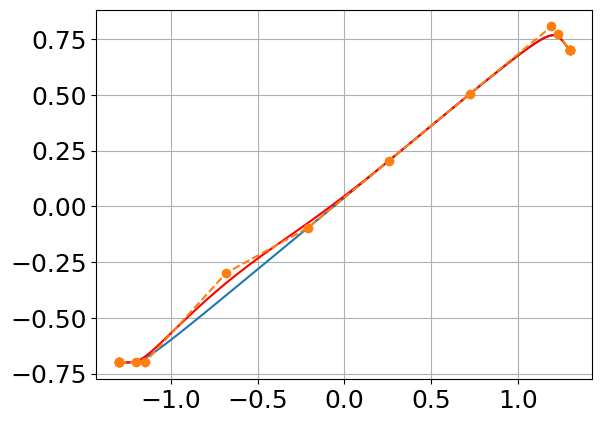

In [8]:
deltaP = np.zeros((NUM_FREE_CTRLPTS, 2))
deltaP[0] = [.0, 0.0]
deltaw = np.zeros(NUM_FREE_CTRLPTS)
deltaw[0] = -0.0
curve = get_nurbs(agent_params1, deltaP, deltaw, Nsampling=NSAMPLING)

plt.plot(*np.array(curve.evalpts).T)
# plt.plot(*np.array(curve.ctrlpts).T, 'o--')
a = curve.ctrlpts
print(np.max(get_curvature_diff(np.array(curve.evalpts))))
deltaP[0] = [0, 0.1]
curve = get_bspline(agent_params1, deltaP, Nsampling=NSAMPLING)

plt.plot(*np.array(curve.evalpts).T, 'r')
plt.plot(*np.array(curve.ctrlpts).T, 'o--')

print(np.max(get_curvature_diff(np.array(curve.evalpts))))


In [11]:
NUM_AGENTS = 1
scale_x = 1.5
scale_y = 1.
xmin_pop = [[-1.0*scale_x, -1.0*scale_y]*(NUM_FREE_CTRLPTS),[1e-5]*(NUM_FREE_CTRLPTS)]
xmin_pop = np.array(flatten_list(xmin_pop))
xmax_pop = [[1.0*scale_x, 1.0*scale_y]*(NUM_FREE_CTRLPTS),[2.0]*(NUM_FREE_CTRLPTS)]
xmax_pop = np.array(flatten_list(xmax_pop))
dim = len(xmin_pop)  # Dimensionality of the problem
colors = randomColor(n=NUM_AGENTS)
dim

12

In [12]:
agents = [ ]
for i in range(NUM_AGENTS):
    idg = i+1
    static_params_i = list_of_static_params[i]
    initial_pop = xmin_pop + np.random.rand(pop_size, dim) * (xmax_pop - xmin_pop)

    for pop_i in initial_pop:
        weight_normalized = pop_i[static_params_i['num_free_ctrlpts']*static_params_i['space_dim']:]
        weight_normalized = weight_normalized/np.max(weight_normalized)
        pop_i[static_params_i['num_free_ctrlpts']*static_params_i['space_dim']:] = weight_normalized.tolist()


    ctrlpts_i = np.zeros((static_params_i['num_free_ctrlpts'], static_params_i['space_dim'])).reshape(-1).tolist()

    weights_i  = np.zeros(static_params_i['num_free_ctrlpts']).reshape(-1).tolist()
    pop_i = ctrlpts_i + weights_i    
    initial_pop[0] = pop_i
    # print(np.array(pop_i).reshape(-1,2))


    agent = LSHADE_COP(
        pop_size=pop_size,
        dim=dim,
        xmin=xmin_pop,
        xmax=xmax_pop,
        max_fes=max_fes,
        func=individual_cost_function,        
        static_params=static_params_i,
        initial_pop=initial_pop.copy(), 
        type_mean=2, 
        type_mutation=1, 
        type_sharing='best',
        
        DEBUG=DEBUG,
        
        color=colors[i],
    )
    agents.append(agent)



In [14]:
agents[0].init_population(shared_pop=[])

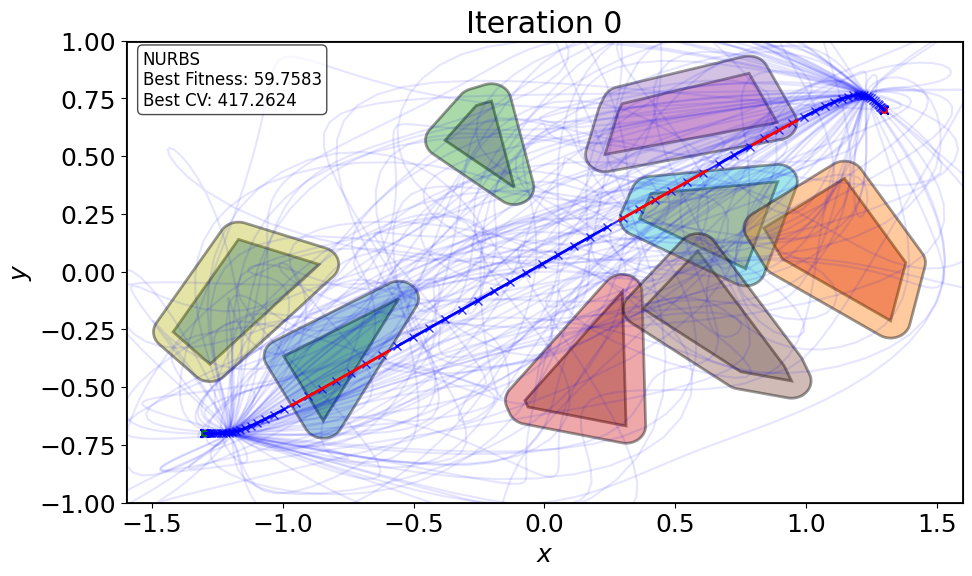

In [15]:
fig, ax = plt.subplots(figsize=(10.8,6))
draw_solutions(agents, iteration=0, ax=ax,show_info=True)

In [30]:

agents[0].run(shared_pop=[])


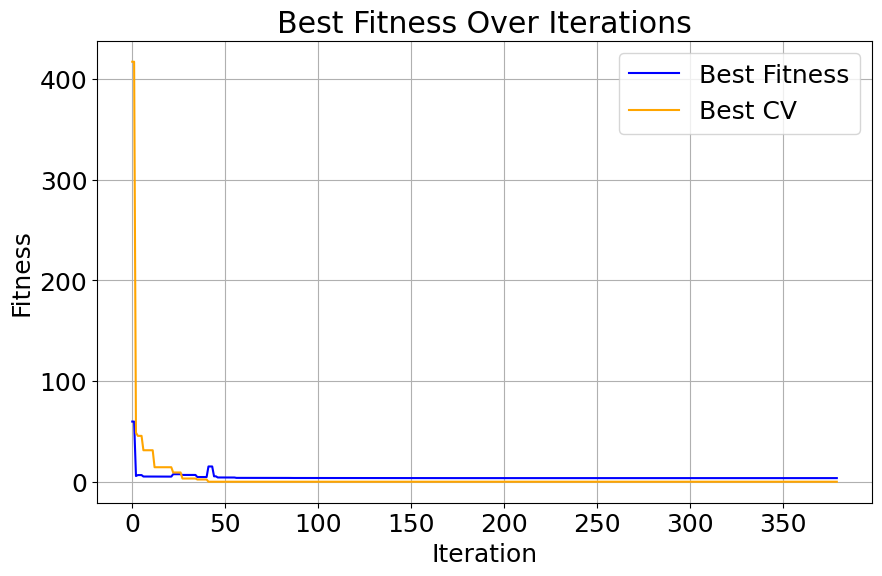

In [31]:
plt.figure(figsize=(10, 6))
plt.plot(agents[0].log_best_f, label='Best Fitness', color=agents[0].color)
plt.plot(agents[0].log_best_CV, label='Best CV', color='orange')
plt.xlabel('Iteration')
plt.ylabel('Fitness')
plt.title('Best Fitness Over Iterations')
plt.legend()
plt.show()

In [32]:
cv = np.array(agents[0].log_best_CV)
cv[cv <= 1e-5] = 0
np.where(cv == 0)[0][0]

41

In [33]:
individual_cost_function(agents[0].P_c, shared_pop=[], static_params=agents[0].static_params)

(array([3.68143883, 3.70678122, 3.72673484, 3.73937962]),
 array([[0.],
        [0.],
        [0.],
        [0.]]),
 array([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]]))

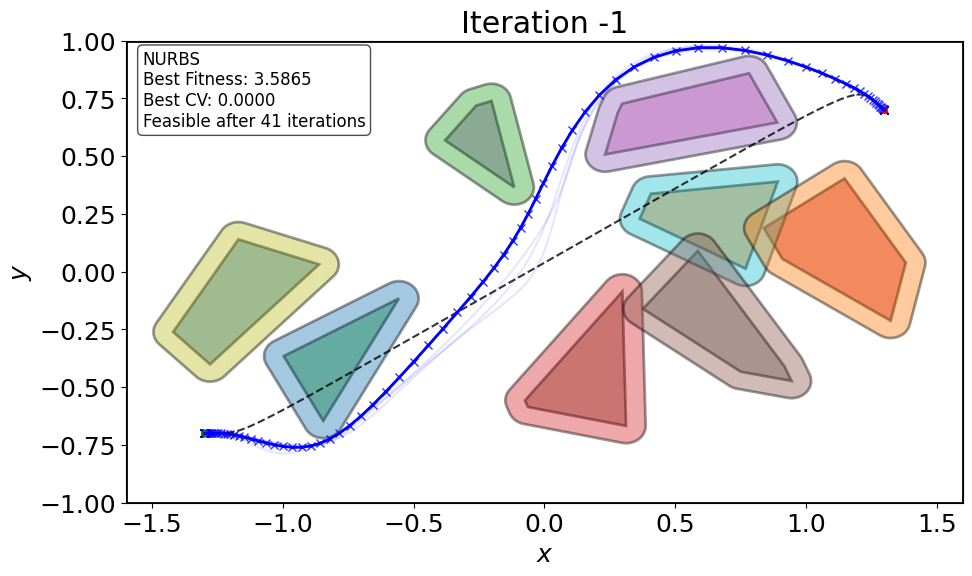

In [34]:
fig, ax = plt.subplots(figsize=(10.8,6))
draw_solutions(agents, iteration=-1, ax=ax, show_initial_solution=True, show_info=True)

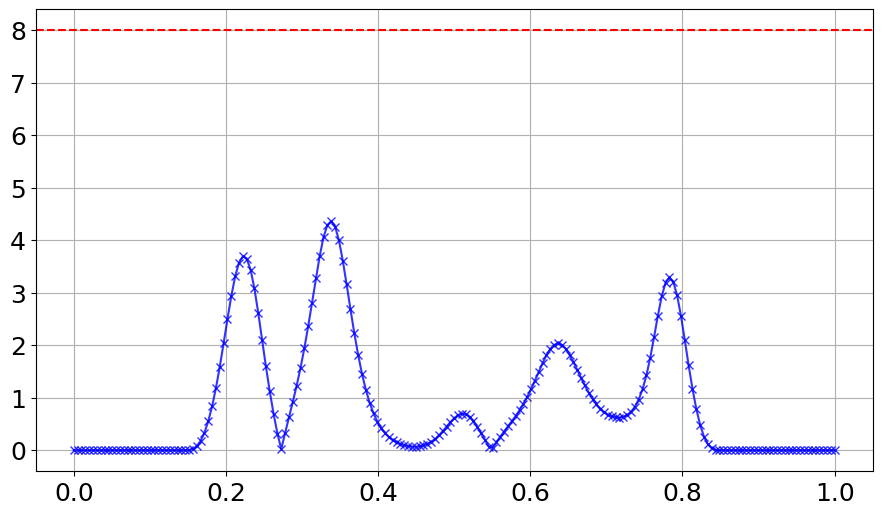

In [35]:
# plot curvature
fig = plt.figure(figsize=(10.8,6))
ax = fig.add_subplot(111)
for agent in agents:
    static_params = agent.static_params
    for ii, ind in enumerate(agent.log_population[-1]):

        points_curve_i, deltaP, deltaw, ctrpts, weights, knots = get_points_from_solution(agent, ind, nsampling=NSAMPLING*2)
        if ii == 0:
            kappa_i = get_curvature_diff(points_curve_i)[1:]
            ax.plot(np.linspace(0, 1, len(kappa_i)), kappa_i, "-x", color=agent.color, alpha=0.8, label=f'Agent {static_params["id"]} Curvature')
            ax.axhline(y=static_params["kappa_max"], color='r', linestyle='--', label='Max Curvature')

In [36]:
len(agents[0].log_population), len(agents[0].log_best_f), len(agents[0].log_best_CV)

(381, 380, 380)

In [37]:
range(len(agents[0].log_population)-1)

range(0, 380)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1080, 600) to (1088, 608) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[swscaler @ 0x224eabc0] Warning: data is not aligned! This can lead to a speed loss


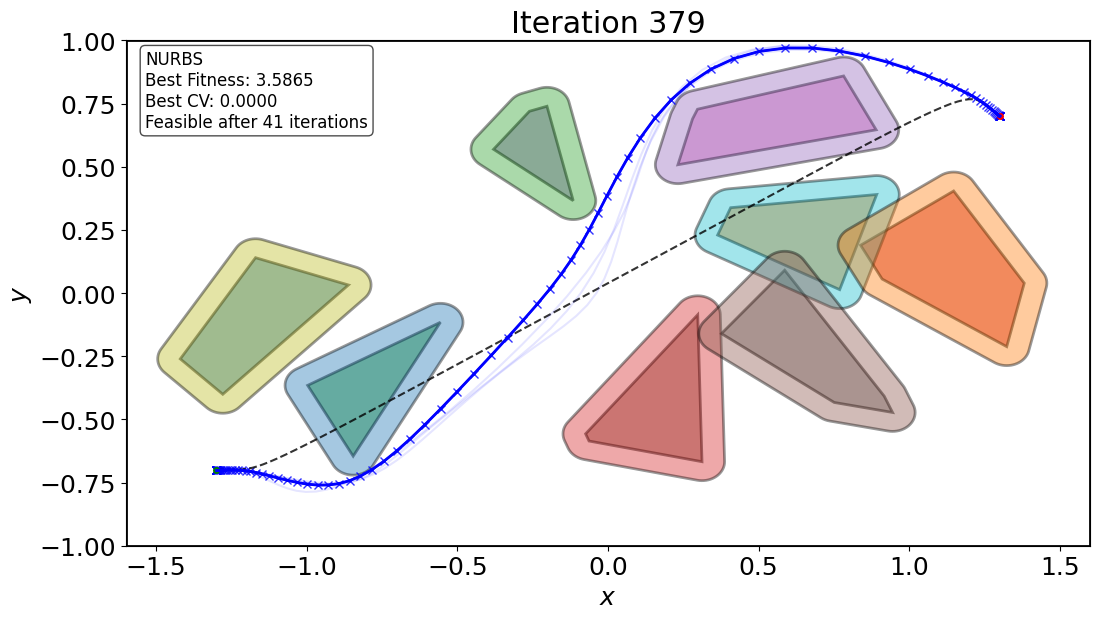

In [ ]:
frames = []
fig = plt.figure(figsize=(10.8,6))
for frame in range(len(agents[0].log_population)-1):
    fig.clear()  
    ax = fig.add_subplot(111)
    draw_solutions(agents, iteration=frame, ax=ax, show_initial_solution=True, show_info=True)    
    fig.tight_layout(pad=0)
    
    fig.canvas.draw()       # draw the canvas, cache the renderer    
    image = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8')
    image  = image.reshape(fig.canvas.get_width_height()[::-1] + (3,)) 
    frames.append(image)  
    

writer = imageio.get_writer("../results/path_convergence_nurbs_"+ str(seed) +".mp4",fps=10)
for _ in range(10):
    writer.append_data(frames[0])
for im in frames:
    writer.append_data(im)
for _ in range(10):
    writer.append_data(frames[-1])

writer.close()

In [38]:
def save_result_for_agents_npy(agents, num_points=NUM_POINTS):
    for agent in agents:        
        best_curve_pts, _, _, ctrlpts, weights, knotvector = get_points_from_solution(agent, agent.log_population[-1][0], nsampling=num_points)
        agent.static_params["best_curve_pts"] = best_curve_pts
        agent.static_params["best_ctrlpts"] = ctrlpts
        agent.static_params["best_weights"] = weights
        agent.static_params["best_knotvector"] = knotvector        
        numpy_array_to_save = np.array(agent.static_params, dtype=object)

        output_file_path = f'../results/test_{seed}/agent_{agent.static_params["id"]}_seed_{seed}.npy'
        np.save(output_file_path, numpy_array_to_save, allow_pickle=True)

        output_file_path = f'./agent_{agent.static_params["id"]}_seed_{seed}.npy'
        np.save(output_file_path, numpy_array_to_save, allow_pickle=True)

In [39]:
save_result_for_agents_npy(agents, num_points= 4000)